In [3]:
#!pip install statsmodels
#!pip install linearmodels


In [4]:
import pandas as pd
import numpy as np
import math
from statsmodels.api import OLS, add_constant
import pandas_datareader.data as web
import lseg.data as ld
from linearmodels.asset_pricing import LinearFactorModel

import matplotlib.pyplot as plt
import seaborn as sns



In [5]:
sns.set_style('whitegrid')

In [8]:
ff_factor = 'F-F_Research_Data_5_Factors_2x3'
ff_factor_data = web.DataReader(ff_factor, 'famafrench', start='2013', end='2026-04')[0]
ff_factor_data.info()

<class 'pandas.core.frame.DataFrame'>
PeriodIndex: 158 entries, 2013-01 to 2026-02
Freq: M
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Mkt-RF  158 non-null    float64
 1   SMB     158 non-null    float64
 2   HML     158 non-null    float64
 3   RMW     158 non-null    float64
 4   CMA     158 non-null    float64
 5   RF      158 non-null    float64
dtypes: float64(6)
memory usage: 8.6 KB


/var/folders/x2/x5jhl2fx0s7f_vgq2d53x7j80000gn/T/ipykernel_15865/822831510.py:2:FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
/var/folders/x2/x5jhl2fx0s7f_vgq2d53x7j80000gn/T/ipykernel_15865/822831510.py:2:FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.


In [9]:
ff_factor_data

,Mkt-RF,SMB,HML,RMW,CMA,RF
Date,,,,,,
2013-01,5.57,0.42,1.01,-2.01,1.52,0.00
2013-02,1.29,-0.25,0.21,-0.59,0.61,0.00
2013-03,4.03,0.88,-0.22,0.27,1.41,0.00
2013-04,1.56,-2.24,0.44,0.39,0.43,0.00
2013-05,2.81,2.04,2.67,-2.00,-0.95,0.00
...,...,...,...,...,...,...
2025-10,1.96,-1.31,-3.10,-5.24,-4.03,0.37
2025-11,-0.13,1.47,3.76,1.44,0.68,0.30
2025-12,-0.36,-0.22,2.42,0.40,0.37,0.34


In [10]:
ff_factor_data.describe()

,Mkt-RF,SMB,HML,RMW,CMA,RF
count,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000
mean,1.094304,-0.154304,-0.053544,0.236266,-0.055253,0.136013
std,4.227311,2.837116,3.486668,2.054332,2.244856,0.159086
min,-13.350000,-8.180000,-13.830000,-5.240000,-7.080000,0.000000
25%,-1.150000,-2.027500,-1.972500,-1.205000,-1.540000,0.000000
50%,1.490000,-0.195000,-0.375000,0.325000,-0.300000,0.060000
75%,3.412500,1.462500,1.715000,1.412500,1.227500,0.267500
max,13.580000,8.340000,12.860000,7.190000,7.730000,0.480000


In [12]:
ld.open_session()

<lseg.data.session.Definition object at 0x13f1d11c0 {name='workspace'}>

In [13]:
dji = ld.get_data('0#.DJI', fields=['TR.CommonName', 'TR.PriceClose',
                                      'TR.Volume', 'TR.TotalReturnYTD'])

In [14]:
dji

,Instrument,Company Common Name,Price Close,Volume,YTD Total Return
0,IBM.N,International Business Machines Corp,246.74,1202935,-16.22134
1,CRM.N,Salesforce Inc,185.03,1925336,-30.153637
2,TRV.N,Travelers Companies Inc,295.55,334375,2.263304
3,V.N,Visa Inc,303.33,1796745,-13.333157
4,NVDA.OQ,NVIDIA Corp,177.64,24653959,-4.74555
5,JNJ.N,Johnson & Johnson,240.97,1643589,17.05338
6,NKE.N,Nike Inc,44.03,4889294,-30.425536
7,SHW.N,Sherwin-Williams Co,316.39,353857,-2.138447
8,BA.N,Boeing Co,212.3,828211,-2.219971
9,GS.N,Goldman Sachs Group Inc,866.05,434917,-0.958735


In [15]:
const = dji['Instrument'].tolist()
const_limp = [i for i in const if i != '']
const_limp

['IBM.N',
 'CRM.N',
 'TRV.N',
 'V.N',
 'NVDA.OQ',
 'JNJ.N',
 'NKE.N',
 'SHW.N',
 'BA.N',
 'GS.N',
 'AXP.N',
 'MRK.N',
 'DIS.N',
 'HON.OQ',
 'CVX.N',
 'AMZN.OQ',
 'AMGN.OQ',
 'CAT.N',
 'WMT.OQ',
 'VZ.N',
 'MSFT.OQ',
 'MCD.N',
 'KO.N',
 'MMM.N',
 'PG.N',
 'CSCO.OQ',
 'UNH.N',
 'HD.N',
 'AAPL.OQ',
 'JPM.N']

In [46]:
from datetime import datetime, timedelta
end = '2026-03-05'
start = '2012-12-01'
print(start, end)

2012-12-01 2026-03-05


In [47]:
df = ld.get_data(const_limp[0], ['TR.TotalReturn.date', "TR.ClosePrice", 'TR.TotalReturn'],
{'SDate': start, 'EDate': end, 'Frq': 'M' })
df

,Instrument,Date,Close Price,Total Return
0,IBM.N,2012-12-31,182.961664,0.77866
1,IBM.N,2013-01-31,193.965153,6.014096
2,IBM.N,2013-02-28,191.825586,-0.684889
3,IBM.N,2013-03-28,203.736481,6.209232
4,IBM.N,2013-04-30,193.458917,-5.044538
...,...,...,...,...
154,IBM.N,2025-10-31,307.41,8.948823
155,IBM.N,2025-11-28,308.58,0.926128
156,IBM.N,2025-12-31,296.21,-4.008685
157,IBM.N,2026-01-30,306.7,3.541406


In [48]:
df = ld.get_data(const_limp[0], ['TR.TotalReturn.date', "TR.ClosePrice", 'TR.TotalReturn'],
{'SDate': start, 'EDate': end, 'Frq': 'M' })
df[const_limp[0]] = np.log((df['Total Return']/100)+1)
monthly_returns = df.drop(['Close Price', 'Total Return', 'Instrument'], axis=1).iloc[1:]
monthly_returns.set_index('Date', inplace = True)
monthly_returns

,IBM.N
Date,
2013-01-31,0.058402
2013-02-28,-0.006872
2013-03-28,0.060241
2013-04-30,-0.051762
2013-05-31,0.031324
...,...
2025-10-31,0.085708
2025-11-28,0.009219
2025-12-31,-0.040912


In [49]:
meses = monthly_returns.count().iloc[0]
meses

np.int64(158)

In [50]:
for i in const_limp[1:]:
    w = ld.get_data(i, ['TR.TotalReturn.date', "TR.ClosePrice", 'TR.TotalReturn'],
{'SDate': start, 'EDate': end, 'Frq': 'M' })
    w = w[w['Total Return'] != 'NaN']
    w[i] = np.log((w['Total Return'].astype(float)/100)+1)
    w1 = w.drop(['Close Price', 'Total Return', 'Instrument'], axis=1).iloc[1:]
    p = round(w1.count().iloc[0])
    print(i, p)
    if p == meses:    
        monthly_returns = monthly_returns.join(w1.set_index('Date'))

CRM.N 158
TRV.N 158
V.N 158
NVDA.OQ 158
JNJ.N 158
NKE.N 158
SHW.N 158
BA.N 158
GS.N 158
AXP.N 158
MRK.N 158
DIS.N 158
HON.OQ 158
CVX.N 158
AMZN.OQ 158
AMGN.OQ 158
CAT.N 158
WMT.OQ 158
VZ.N 158
MSFT.OQ 158
MCD.N 158
KO.N 158
MMM.N 158
PG.N 158
CSCO.OQ 158
UNH.N 158
HD.N 158
AAPL.OQ 158
JPM.N 158


In [51]:
monthly_returns

,IBM.N,CRM.N,TRV.N,V.N,NVDA.OQ,JNJ.N,NKE.N,SHW.N,BA.N,GS.N,...,MSFT.OQ,MCD.N,KO.N,MMM.N,PG.N,CSCO.OQ,UNH.N,HD.N,AAPL.OQ,JPM.N
Date,,,,,,,,,,,,,,,,,,,,,
2013-01-31,0.058402,0.023691,0.088426,0.040912,-0.002444,0.053061,0.046388,0.052677,-0.019970,0.147679,...,0.027308,0.077205,0.026944,0.079670,0.109803,0.045756,0.017725,0.078786,-0.157599,0.074398
2013-02-28,-0.006872,-0.017050,0.024674,0.006742,0.038150,0.037164,0.011406,-0.000196,0.046664,0.016141,...,0.020108,0.014392,0.038973,0.039890,0.013480,0.013520,-0.032397,0.023336,-0.025384,0.038975
2013-03-28,0.060241,0.055236,0.051471,0.068219,0.012559,0.068791,0.080240,0.044185,0.110096,-0.017582,...,0.028720,0.038759,0.050693,0.021968,0.011485,0.002874,0.071875,0.024011,0.002783,-0.030299
2013-04-30,-0.051762,-0.083890,0.014387,-0.008158,0.071486,0.044382,0.074907,0.080839,0.062753,-0.007367,...,0.145777,0.024279,0.045677,-0.015165,0.003999,0.008526,0.046449,0.049895,0.000271,0.038520
2013-05-31,0.031324,0.029245,-0.019985,0.057685,0.055981,-0.004857,-0.027619,0.031750,0.085111,0.107111,...,0.059218,-0.048175,-0.056867,0.057452,-0.000130,0.140676,0.044067,0.069892,0.022186,0.107826
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-10-31,0.085708,0.094197,-0.038702,-0.001877,0.081830,0.018435,-0.076571,-0.003819,-0.071087,-0.008804,...,-0.000270,-0.018130,0.038165,0.070410,-0.014672,0.072318,-0.010890,-0.065264,0.059980,-0.008918
2025-11-28,0.009219,-0.121833,0.086397,-0.016687,-0.134541,0.097544,0.000619,-0.001255,-0.061657,0.045408,...,-0.049209,0.043891,0.059446,0.037136,-0.014806,0.051061,-0.035128,-0.061580,0.031847,0.006280
2025-12-31,-0.040912,0.140578,-0.005663,0.047502,0.052336,0.000145,-0.008087,-0.058904,0.138703,0.067036,...,-0.017200,-0.013942,-0.037830,-0.071987,-0.033283,0.001169,0.007836,-0.030051,-0.025387,0.028776


In [52]:
df2=monthly_returns.reset_index()
df2['Date'] = pd.to_datetime(df2['Date']).dt.to_period('M')
returns = df2.set_index('Date')
returns

,IBM.N,CRM.N,TRV.N,V.N,NVDA.OQ,JNJ.N,NKE.N,SHW.N,BA.N,GS.N,...,MSFT.OQ,MCD.N,KO.N,MMM.N,PG.N,CSCO.OQ,UNH.N,HD.N,AAPL.OQ,JPM.N
Date,,,,,,,,,,,,,,,,,,,,,
2013-01,0.058402,0.023691,0.088426,0.040912,-0.002444,0.053061,0.046388,0.052677,-0.019970,0.147679,...,0.027308,0.077205,0.026944,0.079670,0.109803,0.045756,0.017725,0.078786,-0.157599,0.074398
2013-02,-0.006872,-0.017050,0.024674,0.006742,0.038150,0.037164,0.011406,-0.000196,0.046664,0.016141,...,0.020108,0.014392,0.038973,0.039890,0.013480,0.013520,-0.032397,0.023336,-0.025384,0.038975
2013-03,0.060241,0.055236,0.051471,0.068219,0.012559,0.068791,0.080240,0.044185,0.110096,-0.017582,...,0.028720,0.038759,0.050693,0.021968,0.011485,0.002874,0.071875,0.024011,0.002783,-0.030299
2013-04,-0.051762,-0.083890,0.014387,-0.008158,0.071486,0.044382,0.074907,0.080839,0.062753,-0.007367,...,0.145777,0.024279,0.045677,-0.015165,0.003999,0.008526,0.046449,0.049895,0.000271,0.038520
2013-05,0.031324,0.029245,-0.019985,0.057685,0.055981,-0.004857,-0.027619,0.031750,0.085111,0.107111,...,0.059218,-0.048175,-0.056867,0.057452,-0.000130,0.140676,0.044067,0.069892,0.022186,0.107826
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-10,0.085708,0.094197,-0.038702,-0.001877,0.081830,0.018435,-0.076571,-0.003819,-0.071087,-0.008804,...,-0.000270,-0.018130,0.038165,0.070410,-0.014672,0.072318,-0.010890,-0.065264,0.059980,-0.008918
2025-11,0.009219,-0.121833,0.086397,-0.016687,-0.134541,0.097544,0.000619,-0.001255,-0.061657,0.045408,...,-0.049209,0.043891,0.059446,0.037136,-0.014806,0.051061,-0.035128,-0.061580,0.031847,0.006280
2025-12,-0.040912,0.140578,-0.005663,0.047502,0.052336,0.000145,-0.008087,-0.058904,0.138703,0.067036,...,-0.017200,-0.013942,-0.037830,-0.071987,-0.033283,0.001169,0.007836,-0.030051,-0.025387,0.028776


In [53]:
excess_returns = returns.sub(ff_factor_data.RF, axis=0)
excess_returns

,IBM.N,CRM.N,TRV.N,V.N,NVDA.OQ,JNJ.N,NKE.N,SHW.N,BA.N,GS.N,...,MSFT.OQ,MCD.N,KO.N,MMM.N,PG.N,CSCO.OQ,UNH.N,HD.N,AAPL.OQ,JPM.N
Date,,,,,,,,,,,,,,,,,,,,,
2013-01,0.058402,0.023691,0.088426,0.040912,-0.002444,0.053061,0.046388,0.052677,-0.019970,0.147679,...,0.027308,0.077205,0.026944,0.079670,0.109803,0.045756,0.017725,0.078786,-0.157599,0.074398
2013-02,-0.006872,-0.017050,0.024674,0.006742,0.038150,0.037164,0.011406,-0.000196,0.046664,0.016141,...,0.020108,0.014392,0.038973,0.039890,0.013480,0.013520,-0.032397,0.023336,-0.025384,0.038975
2013-03,0.060241,0.055236,0.051471,0.068219,0.012559,0.068791,0.080240,0.044185,0.110096,-0.017582,...,0.028720,0.038759,0.050693,0.021968,0.011485,0.002874,0.071875,0.024011,0.002783,-0.030299
2013-04,-0.051762,-0.083890,0.014387,-0.008158,0.071486,0.044382,0.074907,0.080839,0.062753,-0.007367,...,0.145777,0.024279,0.045677,-0.015165,0.003999,0.008526,0.046449,0.049895,0.000271,0.038520
2013-05,0.031324,0.029245,-0.019985,0.057685,0.055981,-0.004857,-0.027619,0.031750,0.085111,0.107111,...,0.059218,-0.048175,-0.056867,0.057452,-0.000130,0.140676,0.044067,0.069892,0.022186,0.107826
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-10,-0.284292,-0.275803,-0.408702,-0.371877,-0.288170,-0.351565,-0.446571,-0.373819,-0.441087,-0.378804,...,-0.370270,-0.388130,-0.331835,-0.299590,-0.384672,-0.297682,-0.380890,-0.435264,-0.310020,-0.378918
2025-11,-0.290781,-0.421833,-0.213603,-0.316687,-0.434541,-0.202456,-0.299381,-0.301255,-0.361657,-0.254592,...,-0.349209,-0.256109,-0.240554,-0.262864,-0.314806,-0.248939,-0.335128,-0.361580,-0.268153,-0.293720
2025-12,-0.380912,-0.199422,-0.345663,-0.292498,-0.287664,-0.339855,-0.348087,-0.398904,-0.201297,-0.272964,...,-0.357200,-0.353942,-0.377830,-0.411987,-0.373283,-0.338831,-0.332164,-0.370051,-0.365387,-0.311224


In [54]:
excess_returns = excess_returns.clip(lower=np.percentile(excess_returns, 1),
                                     upper=np.percentile(excess_returns, 99))

# excess_returns

In [55]:
const = dji['Instrument'].tolist()
const_limp = [i for i in const if i != '']
const_limp

['IBM.N',
 'CRM.N',
 'TRV.N',
 'V.N',
 'NVDA.OQ',
 'JNJ.N',
 'NKE.N',
 'SHW.N',
 'BA.N',
 'GS.N',
 'AXP.N',
 'MRK.N',
 'DIS.N',
 'HON.OQ',
 'CVX.N',
 'AMZN.OQ',
 'AMGN.OQ',
 'CAT.N',
 'WMT.OQ',
 'VZ.N',
 'MSFT.OQ',
 'MCD.N',
 'KO.N',
 'MMM.N',
 'PG.N',
 'CSCO.OQ',
 'UNH.N',
 'HD.N',
 'AAPL.OQ',
 'JPM.N']

In [56]:
betas = []
for i in excess_returns.columns:
    step1 = OLS(endog=excess_returns.loc[:,i].astype(float), 
                exog=add_constant(ff_factor_data)).fit()
    betas.append(step1.params.drop('const'))
betas

## Y es el rendimiento de comapañía i  = B0 Mft-RF + B1 SMB + B2 HML + B3 RMW + B4 CMA + B5 RF + e


[Mkt-RF    0.009352
 SMB      -0.003348
 HML       0.004356
 RMW      -0.000789
 CMA      -0.001382
 RF       -0.942829
 dtype: float64,
 Mkt-RF    0.010912
 SMB      -0.003768
 HML      -0.001510
 RMW      -0.006358
 CMA      -0.010594
 RF       -1.012772
 dtype: float64,
 Mkt-RF    0.007251
 SMB      -0.001036
 HML       0.004654
 RMW      -0.000338
 CMA       0.003156
 RF       -0.982639
 dtype: float64,
 Mkt-RF    0.009102
 SMB      -0.003531
 HML       0.000515
 RMW      -0.000006
 CMA      -0.001091
 RF       -1.006280
 dtype: float64,
 Mkt-RF    0.016239
 SMB      -0.002968
 HML      -0.005168
 RMW       0.001086
 CMA      -0.007473
 RF       -0.948476
 dtype: float64,
 Mkt-RF    0.006159
 SMB      -0.001873
 HML       0.000054
 RMW       0.002373
 CMA       0.006164
 RF       -1.000005
 dtype: float64,
 Mkt-RF    0.009992
 SMB       0.001812
 HML      -0.005347
 RMW       0.006602
 CMA       0.006124
 RF       -1.034199
 dtype: float64,
 Mkt-RF    0.010165
 SMB       0.003732
 

In [57]:
betas = pd.DataFrame(betas, 
                     columns=ff_factor_data.columns, 
                     index=excess_returns.columns)
betas

,Mkt-RF,SMB,HML,RMW,CMA,RF
IBM.N,0.009352,-0.003348,0.004356,-0.000789,-0.001382,-0.942829
CRM.N,0.010912,-0.003768,-0.001510,-0.006358,-0.010594,-1.012772
TRV.N,0.007251,-0.001036,0.004654,-0.000338,0.003156,-0.982639
V.N,0.009102,-0.003531,0.000515,-0.000006,-0.001091,-1.006280
NVDA.OQ,0.016239,-0.002968,-0.005168,0.001086,-0.007473,-0.948476
JNJ.N,0.006159,-0.001873,0.000054,0.002373,0.006164,-1.000005
NKE.N,0.009992,0.001812,-0.005347,0.006602,0.006124,-1.034199
SHW.N,0.010165,0.003732,-0.000765,0.007344,0.001361,-0.977600
BA.N,0.010688,0.002685,0.003521,0.004260,-0.002989,-0.968735
GS.N,0.013021,0.000144,0.008889,-0.004092,-0.004512,-0.965323


In [58]:
excess_returns.index

PeriodIndex(['2013-01', '2013-02', '2013-03', '2013-04', '2013-05', '2013-06',
             '2013-07', '2013-08', '2013-09', '2013-10',
             ...
             '2025-05', '2025-06', '2025-07', '2025-08', '2025-09', '2025-10',
             '2025-11', '2025-12', '2026-01', '2026-02'],
            dtype='period[M]', name='Date', length=158)

In [59]:
for period in betas.index:
    print(period)

IBM.N
CRM.N
TRV.N
V.N
NVDA.OQ
JNJ.N
NKE.N
SHW.N
BA.N
GS.N
AXP.N
MRK.N
DIS.N
HON.OQ
CVX.N
AMZN.OQ
AMGN.OQ
CAT.N
WMT.OQ
VZ.N
MSFT.OQ
MCD.N
KO.N
MMM.N
PG.N
CSCO.OQ
UNH.N
HD.N
AAPL.OQ
JPM.N


In [60]:
for period in excess_returns.index:
    print(period)

2013-01
2013-02
2013-03
2013-04
2013-05
2013-06
2013-07
2013-08
2013-09
2013-10
2013-11
2013-12
2014-01
2014-02
2014-03
2014-04
2014-05
2014-06
2014-07
2014-08
2014-09
2014-10
2014-11
2014-12
2015-01
2015-02
2015-03
2015-04
2015-05
2015-06
2015-07
2015-08
2015-09
2015-10
2015-11
2015-12
2016-01
2016-02
2016-03
2016-04
2016-05
2016-06
2016-07
2016-08
2016-09
2016-10
2016-11
2016-12
2017-01
2017-02
2017-03
2017-04
2017-05
2017-06
2017-07
2017-08
2017-09
2017-10
2017-11
2017-12
2018-01
2018-02
2018-03
2018-04
2018-05
2018-06
2018-07
2018-08
2018-09
2018-10
2018-11
2018-12
2019-01
2019-02
2019-03
2019-04
2019-05
2019-06
2019-07
2019-08
2019-09
2019-10
2019-11
2019-12
2020-01
2020-02
2020-03
2020-04
2020-05
2020-06
2020-07
2020-08
2020-09
2020-10
2020-11
2020-12
2021-01
2021-02
2021-03
2021-04
2021-05
2021-06
2021-07
2021-08
2021-09
2021-10
2021-11
2021-12
2022-01
2022-02
2022-03
2022-04
2022-05
2022-06
2022-07
2022-08
2022-09
2022-10
2022-11
2022-12
2023-01
2023-02
2023-03
2023-04
2023-05


In [61]:
excess_returns.index[0]

Period('2013-01', 'M')

In [62]:
betas.index

Index(['IBM.N', 'CRM.N', 'TRV.N', 'V.N', 'NVDA.OQ', 'JNJ.N', 'NKE.N', 'SHW.N',
       'BA.N', 'GS.N', 'AXP.N', 'MRK.N', 'DIS.N', 'HON.OQ', 'CVX.N', 'AMZN.OQ',
       'AMGN.OQ', 'CAT.N', 'WMT.OQ', 'VZ.N', 'MSFT.OQ', 'MCD.N', 'KO.N',
       'MMM.N', 'PG.N', 'CSCO.OQ', 'UNH.N', 'HD.N', 'AAPL.OQ', 'JPM.N'],
      dtype='object')

In [63]:
excess_returns.loc['2012-01', betas.index]

KeyError: '2012-01'

In [64]:
betas

,Mkt-RF,SMB,HML,RMW,CMA,RF
IBM.N,0.009352,-0.003348,0.004356,-0.000789,-0.001382,-0.942829
CRM.N,0.010912,-0.003768,-0.001510,-0.006358,-0.010594,-1.012772
TRV.N,0.007251,-0.001036,0.004654,-0.000338,0.003156,-0.982639
V.N,0.009102,-0.003531,0.000515,-0.000006,-0.001091,-1.006280
NVDA.OQ,0.016239,-0.002968,-0.005168,0.001086,-0.007473,-0.948476
JNJ.N,0.006159,-0.001873,0.000054,0.002373,0.006164,-1.000005
NKE.N,0.009992,0.001812,-0.005347,0.006602,0.006124,-1.034199
SHW.N,0.010165,0.003732,-0.000765,0.007344,0.001361,-0.977600
BA.N,0.010688,0.002685,0.003521,0.004260,-0.002989,-0.968735
GS.N,0.013021,0.000144,0.008889,-0.004092,-0.004512,-0.965323


In [65]:
lambdas = []
for period in excess_returns.index:
    step2 = OLS(endog=excess_returns.loc[period, betas.index].astype(float), 
                exog=betas).fit()
    lambdas.append(step2.params)

In [66]:
lambdas

[Mkt-RF    1.543452
 SMB       1.305417
 HML       4.019052
 RMW      -3.982682
 CMA       4.132841
 RF       -0.029576
 dtype: float64,
 Mkt-RF    2.231380
 SMB      -4.570902
 HML       3.067644
 RMW       2.704917
 CMA       1.192024
 RF        0.016439
 dtype: float64,
 Mkt-RF   -6.886417
 SMB       2.698384
 HML      -1.941443
 RMW      -0.960885
 CMA      -1.198947
 RF       -0.111570
 dtype: float64,
 Mkt-RF    5.038031
 SMB      -5.181513
 HML       0.626702
 RMW       4.145703
 CMA       3.503699
 RF        0.034249
 dtype: float64,
 Mkt-RF    3.945796
 SMB       6.054583
 HML       1.954486
 RMW      -1.063523
 CMA      -4.618302
 RF       -0.003086
 dtype: float64,
 Mkt-RF   -5.667884
 SMB       1.252934
 HML      -1.713785
 RMW      -1.371476
 CMA       1.036404
 RF       -0.042856
 dtype: float64,
 Mkt-RF   -7.197322
 SMB       9.865104
 HML      -3.290285
 RMW      -5.839480
 CMA      -3.023651
 RF       -0.130372
 dtype: float64,
 Mkt-RF   -0.207912
 SMB       1.140118
 

In [67]:
lambdas = pd.DataFrame(lambdas, 
                       index=returns.index,
                       columns=betas.columns.tolist())
lambdas

,Mkt-RF,SMB,HML,RMW,CMA,RF
Date,,,,,,
2013-01,1.543452,1.305417,4.019052,-3.982682,4.132841,-0.029576
2013-02,2.231380,-4.570902,3.067644,2.704917,1.192024,0.016439
2013-03,-6.886417,2.698384,-1.941443,-0.960885,-1.198947,-0.111570
2013-04,5.038031,-5.181513,0.626702,4.145703,3.503699,0.034249
2013-05,3.945796,6.054583,1.954486,-1.063523,-4.618302,-0.003086
...,...,...,...,...,...,...
2025-10,3.640805,1.360036,-4.642517,-6.315409,-0.265284,0.376478
2025-11,-10.030354,-0.212052,0.573829,-3.920836,6.813364,0.204846
2025-12,-2.787497,4.005589,-1.993738,-5.699355,-4.306765,0.293391


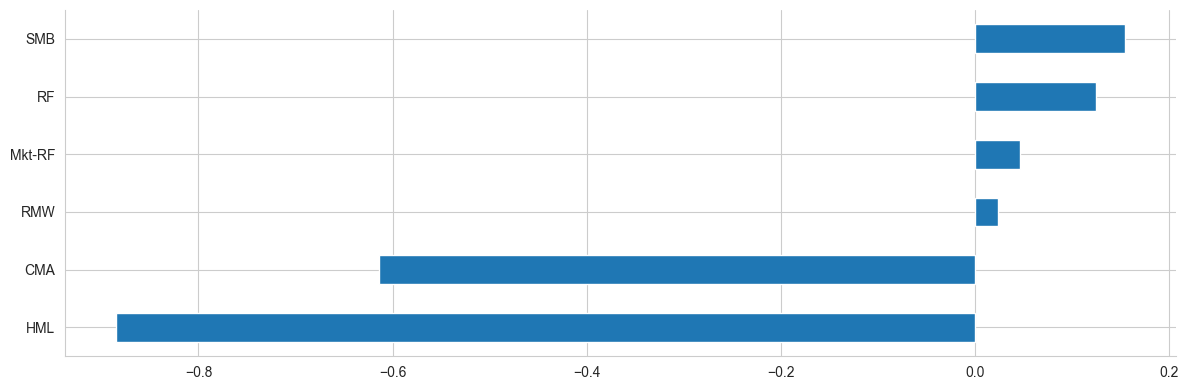

In [68]:
lambdas.mean().sort_values().plot.barh(figsize=(12, 4))
sns.despine()
plt.tight_layout();

In [69]:
t = lambdas.mean().div(lambdas.std())
t

Mkt-RF    0.005673
SMB       0.027528
HML      -0.200627
RMW       0.005828
CMA      -0.160087
RF        0.709439
dtype: float64

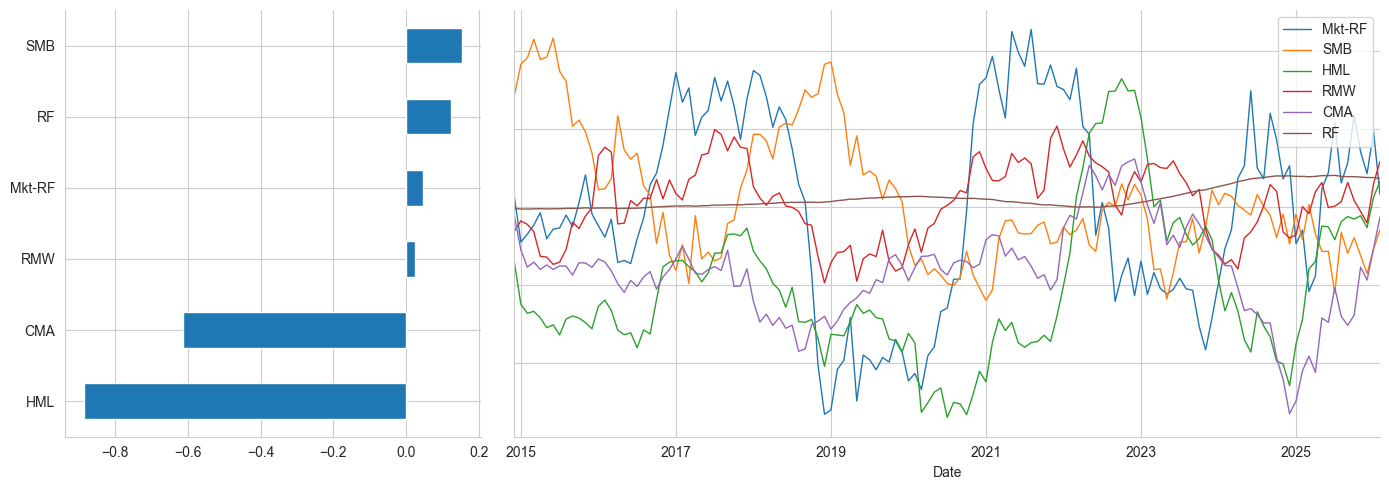

In [70]:
window = 24  # months
ax1 = plt.subplot2grid((1, 3), (0, 0))
ax2 = plt.subplot2grid((1, 3), (0, 1), colspan=2)
lambdas.mean().sort_values().plot.barh(ax=ax1)
lambdas.rolling(window).mean().dropna().plot(lw=1,
                                             figsize=(14, 5),
                                             sharey=True,
                                             ax=ax2)
sns.despine()
plt.tight_layout()

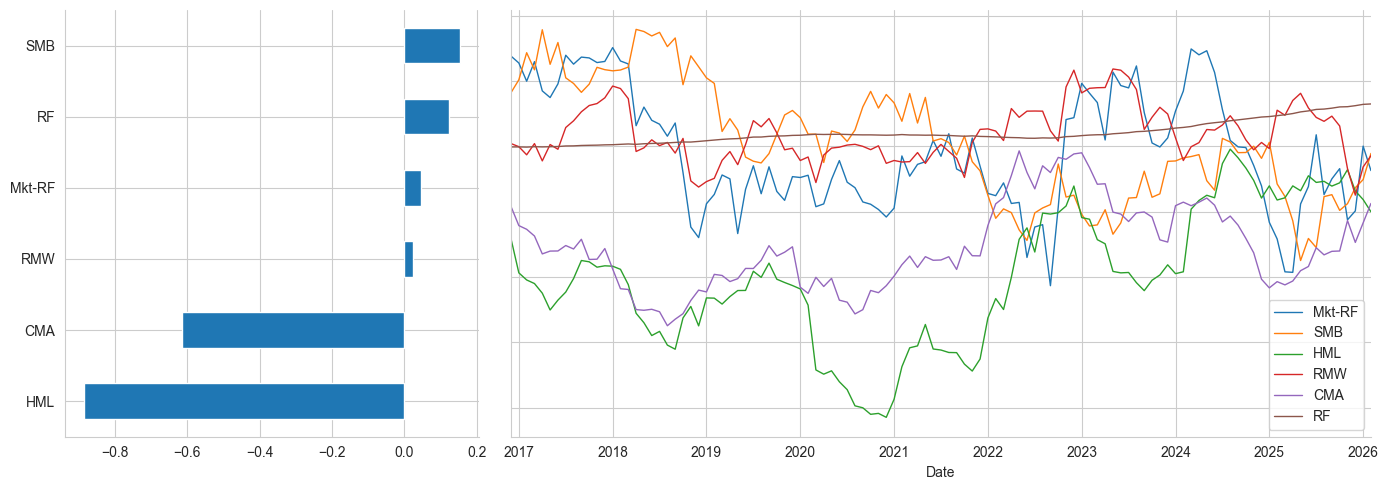

In [71]:
window = 48  # months
ax1 = plt.subplot2grid((1, 3), (0, 0))
ax2 = plt.subplot2grid((1, 3), (0, 1), colspan=2)
lambdas.mean().sort_values().plot.barh(ax=ax1)
lambdas.rolling(window).mean().dropna().plot(lw=1,
                                             figsize=(14, 5),
                                             sharey=True,
                                             ax=ax2)
sns.despine()
plt.tight_layout()

In [72]:
mod = LinearFactorModel(portfolios=excess_returns, 
                        factors=ff_factor_data)
res = mod.fit()
print(res)

                      LinearFactorModel Estimation Summary                      
No. Test Portfolios:                 30   R-squared:                      0.9164
No. Factors:                          6   J-statistic:                    55.043
No. Observations:                   158   P-value                         0.0003
Date:                  Mon, Apr 06 2026   Distribution:                 chi2(24)
Time:                          17:54:35                                         
Cov. Estimator:                  robust                                         
                                                                                
                            Risk Premia Estimates                             
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
Mkt-RF         0.0458     0.7677     0.0596     0.9524     -1.4589      1.5504
SMB            0.1545     0.6668    

In [73]:
print(res.full_summary)


                      LinearFactorModel Estimation Summary                      
No. Test Portfolios:                 30   R-squared:                      0.9164
No. Factors:                          6   J-statistic:                    55.043
No. Observations:                   158   P-value                         0.0003
Date:                  Mon, Apr 06 2026   Distribution:                 chi2(24)
Time:                          17:54:35                                         
Cov. Estimator:                  robust                                         
                                                                                
                            Risk Premia Estimates                             
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
Mkt-RF         0.0458     0.7677     0.0596     0.9524     -1.4589      1.5504
SMB            0.1545     0.6668    